# Bai thuc hanh phan mo hinh PERCEPTRON

## Vi du 1:
- Xây dựng mô hình Perceptron từ các thư viện cơ sở và thực hiện phân loại dữ liệu nhân tạo để
minh họa. Trong ví dụ này, chúng ta sẽ tạo một tập dữ liệu ngẫu nhiên 02 chiều, với phân bố chuẩn có kỳ
vọng là các điểm tương đối biệt lập và ma trận hiệp phương sai phù hợp để đám bảo dữ liệu hầu như tách
được tuyến tính. Dưới đây là đoạn chương trình liên kết các thư viện và tạo dữ liệu:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(2)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 30
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T
X = np.concatenate((X0, X1), axis = 1)

y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)


(3, 60)


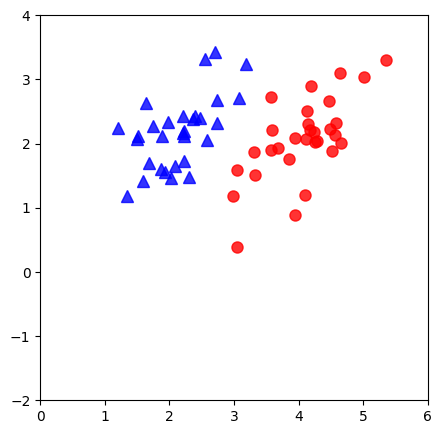

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ani = plt.cla()
#plot points
ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
ani = plt.axis([0 , 6, -2, 4])
plt.show()

- Xây dựng hàm y = hw(x) = w0 + wTx = ẅTẍ

In [12]:
# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))

- Ham kiem tra dieu kien dung

In [13]:
#Stop condition
def has_converged(X, y, w):
    return np.array_equal(h(w, X), y) #True if h(w, X) == y else False

- Vòng lặp chính tìm đường phân chia (bộ hệ số W) theo phương pháp Gradient Descent

In [14]:
def perceptron(X, y, w_init):
    w = [w_init]
    N = X.shape[1]
    mis_points = [] # set of miss position points
    while True:
        # mix data
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(3, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)
        if has_converged(X, y, w[-1]):
            break
    return (w, mis_points)

- Gọi hàm lặp và in ra kết quả là bộ trọng số W ở vòng lặp cuối

In [15]:
d = X.shape[0]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(X, y, w_init)
print(w[-1])

[[ 13.97858527]
 [-15.02901929]
 [ 14.38743059]]


- Tiếp theo chúng ta xây dựng phương thức vẽ đường phân chia để quan sát kết quả

In [16]:
def draw_line(w):
    w0, w1, w2 = w[0], w[1], w[2]
    if w2 != 0:
        x11, x12 = -100, 100
        return plt.plot([x11, x12], [-(w1*x11 + w0)/w2, -(w1*x12 + w0)/w2], 'k')
    else:
        x10 = -w0/w1
        return plt.plot([x10, x10], [-100, 100], 'k')

- Trong phần cuối, chúng ta sẽ hiển thị kết quả dạng ảnh động (gif) để quan sát sự thay đổi của đường phân
chia qua từng bước lặp. Tên ảnh kết quả sẽ là 'pla_vis.gif', trong chương trình này ảnh được lưu vào ổ
D:\. Các bạn sửa đường dẫn. Khi chương trình kết thúc đường phân chia cuối cùng sẽ được vẽ ra. Chúng
ta sử dụng thư viện matplotlib.animation để tạo gif

MovieWriter imagemagick unavailable; using Pillow instead.


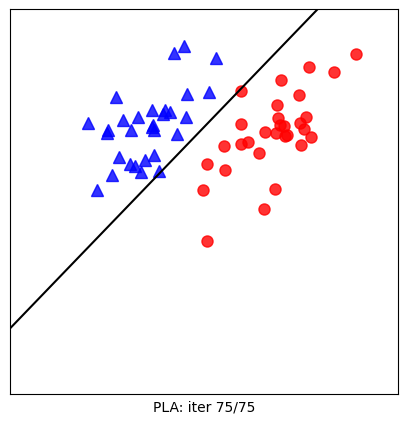

In [20]:
# Visualization
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

def viz_alg_1d_2(w):
    it = len(w)
    fig, ax = plt.subplots(figsize=(5,5))
    
    def update(i):
        ani = plt.cla()
        #points 
        ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize =  8, alpha = .8)
        ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize =  8, alpha = .8)
        ani = plt.axis([0 , 6, -2, 4])
        i2 = i if i < it else it-1
        ani = draw_line(w[i2])
        if i < it-1:
            # draw one misclassified point
            circle = plt.Circle((X[1, m[i]], X[2, m[i]]), 0.15, color='k', fill =
            False)
            ax.add_artist(circle)
        # hide axis
        cur_axes = plt.gca()
        cur_axes.axes.get_xaxis().set_ticks([])
        cur_axes.axes.get_yaxis().set_ticks([])
        label = 'PLA: iter %d/%d' %(i2, it-1)
        ax.set_xlabel(label)
        return ani, ax
    anim = FuncAnimation(fig, update, frames=np.arange(0, it + 2), interval=1000)
    # save
    anim.save('/home/datbritget/Downloads/perceptron.gif', dpi = 100, writer = 'imagemagick')
    plt.show()

viz_alg_1d_2(w)

## Vi du 2:
- Trong ví dụ dưới đây chúng ta sử dụng dữ liệu sóng thủy âm Sonar. Tệp dữ liệu có 60 cột ứng
với 60 thuộc tính (trường) không có tiêu đề, là tham số của các mẫu sóng âm phản hồi; cột thứ 61 là đầu
ra phân loại (y), với ký tự “R” nghĩa là Rock; ký tự “M” nghĩa là Mine (vật thể kim loại hình trụ). Toàn
bộ tệp có 208 bản ghi. Thông tin thêm về dữ liệu có thể tìm hiểu tại link
https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks) hoặc có thể lấy
trong tệp Sonar.all-data.csv đính kèm

- Trong ví dụ này chúng ta sử dụng thư viện matplotlib và seaborn để thực hiện việc hiển thị trực quan cấu
trúc dữ liệu (tham khảo lại bài thực hành phần PCA)

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
main_df = pd.read_csv('/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/ex7/sonar.all-data.csv', header = None)
main_df

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


- Chúng ta sẽ kiểm tra độ cân bằng của dữ liệu bằng cách nhóm theo cột cuối cùng (chỉ số cột là 60 – tính
từ không), tức là cột đầu ra y:

<Axes: ylabel='60'>

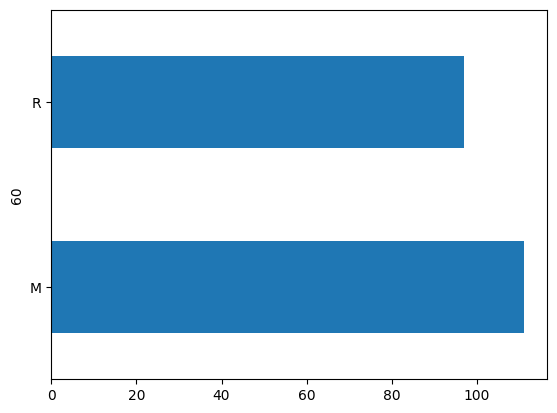

In [9]:
main_df[60].value_counts().plot(kind = 'barh')

In [10]:
y_df = main_df[60]
targes_label = {'M':1, 'R':1}
targes_df = [targes_label[item] for item in y_df]

print(targes_df)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


- lay phan du lieu quan sat (bo cot 60)

In [11]:
inputs_df = main_df.drop(60, axis=1)

- Sau do bo sung them truong du lieu x0 = 1 vao ben trai

In [12]:
inputs_df = main_df.drop(60, axis=1)
x0 = np.ones(( inputs_df.shape[0], 1))
X = np.concatenate((x0, inputs_df), axis = 1)

- Số chiều dữ liệu hiện tại sẽ là 61 (trường) x 208 (bản ghi). Chúng ta chia dữ liệu thành tập train : test với
tỷ lệ là 7:3


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, targes_df, test_size=0.30,
random_state=42)

### Bai tap thuc hanh
#### a. 
- Tiếp theo, các bạn hãy sử dụng các hàm đã có ở Ví dụ 1, sau đó huấn luyện mô hình bằng tập dữ
liệu X_train, y_train. Chú ý chúng ta cần bỏ qua các phần lệnh phục vụ việc hiển thị kết quả dạng
hình vẽ.